# Ablation Study using Latest 2026 paper with Manual Groud Truth
This is the benchmark that check the effect of flitering/no filtering, prompt/model effect, normalizaiton/no normalization. The groud truth here are manully evaluated to mimic the real-case senario, without the need for PubTator/TmVar or ClinVar label. Paper are chosen from the lastest PMC in 2026 to avoid data-leakage.

In [1]:
import pandas as pd
from transformers import AutoTokenizer,AutoModelForSequenceClassification,AutoConfig
from vllm import LLM, SamplingParams
import torch
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
def get_full_text_paragraphs(nxml):
    
    nxml_files = nxml

    if nxml_files:
        with open(nxml_files, "r", encoding="utf-8") as file:
            content = file.read()
        soup = BeautifulSoup(content, "xml")
        
        
        # Extract paragraphs
        paragraphs = []
        
        abstract_section = soup.find("abstract")
        if abstract_section:
            abstract_text = abstract_section.get_text(separator=" ", strip=True)
            #if keep_paragraph_bert(abstract_text):
            paragraphs.append({"section": "abstract", "paragraph": abstract_text})
            
        for sec in soup.find_all("sec"):
            section_title = sec.find("title").get_text(strip=True) if sec.find("title") else "No Title"

            # Skip irrelevant sections
            section_not_interest = ["method", "acknowledgment", "reference"]
            if any(sec_name in section_title.lower() for sec_name in section_not_interest):
                continue
            
            valid_sections = ["abstract", "introduction", "method", "result", "discussion", "conclusion"
                             "methods", "results", "discussions"]
            if not any(sec == section_title.lower() for sec in valid_sections):
                    section_title = "Others"
            for p in sec.find_all("p"):
                paragraph_text = p.get_text(separator=" ", strip=True)
                #if keep_paragraph_bert(paragraph_text):
                paragraphs.append({"section": section_title, "paragraph": paragraph_text})

        # Convert to DataFrame
        df = pd.DataFrame(paragraphs,columns=['section','paragraph'])
        
        unknown_section_mask = df["section"] == "Others"

        # Drop duplicates only in "Others"
        df_sort = pd.concat([
            df[~unknown_section_mask],  
            df[unknown_section_mask].drop_duplicates(subset=["paragraph"]) # make sure "Others" rank at the bottom
        ])

        df_sort = df_sort.drop_duplicates(subset=["paragraph"], keep="first").reset_index(drop=True)

        return df_sort

    return pd.DataFrame(columns=["section", "paragraph"])

### Paper 1: PMC12858432
https://pmc.ncbi.nlm.nih.gov/articles/PMC12858432/ \
A Novel AP4M1 Variant in an Iranian Child with Spastic Paraplegia 50: A Case Report and Molecular Docking Approach
### Paper 2: PMC12992144
https://pmc.ncbi.nlm.nih.gov/articles/PMC12992144/ \
A novel de novo ATP2B1 variant causes autosomal dominant intellectual developmental disorder 66 by disrupting calcium homeostasis via impaired membrane trafficking
### Paper 3: PMC13044143
https://pmc.ncbi.nlm.nih.gov/articles/PMC13044143/ \
Case Report: First report of a novel homozygous nonsense mutation in the CYBA gene causing chronic granulomatous disease

In [3]:
pmcids = ["PMC13044143", "PMC12992144", "PMC12858432"]
dfs = []
base_dir = Path("./2026_pmc_paper")

for pmcid in pmcids:
    pmc_dir = base_dir / pmcid
    
    # find the nxml file 
    nxml_files = list(pmc_dir.glob("*.nxml"))
    
    if not nxml_files:
        print(f"No nxml found for {pmcid}")
        continue
    
    nxml_path = nxml_files[0]
    df = get_full_text_paragraphs(str(nxml_path))
    
    # add PMCID column
    df["PMCID"] = pmcid
    
    dfs.append(df)

# concatenate all
final_df = pd.concat(dfs, ignore_index=True)

### checking the number of words(tokens) in total for each paper per section

In [31]:
final_df['words'] = final_df['paragraph'].str.count(' ') + 1

In [33]:
final_df.groupby(['PMCID','section'])['words'].sum()

PMCID        section     
PMC12858432  Discussion       530
             Introduction     378
             Others          1109
             abstract         162
PMC12992144  Discussion      1380
             Introduction     656
             Others          1621
             Results         1330
             abstract         212
PMC13044143  Discussion      1399
             Introduction     603
             Others          1746
             Results          986
             abstract         169
Name: words, dtype: int64

In [35]:
final_df.groupby(['PMCID'])['words'].sum()

PMCID
PMC12858432    2179
PMC12992144    5199
PMC13044143    4903
Name: words, dtype: int64

## Loading LLM (meta-llama/Llama-3.3-70B-Instruct)

In [5]:
# Initialize the model

model = LLM("/mnt/isilon/wang_lab/shared/Llama3_3/Llama-3.3-70B-Instruct/", # meta-llama/Llama-3.3-70B-Instruct
    tensor_parallel_size=4, #change it to number of GPU
    max_model_len=10000,
    swap_space=0,
    gpu_memory_utilization = 0.9
)

INFO 04-14 14:59:56 config.py:905] Defaulting to use mp for distributed inference
INFO 04-14 14:59:56 llm_engine.py:237] Initializing an LLM engine (v0.6.3.post1) with config: model='/mnt/isilon/wang_lab/shared/Llama3_3/Llama-3.3-70B-Instruct/', speculative_config=None, tokenizer='/mnt/isilon/wang_lab/shared/Llama3_3/Llama-3.3-70B-Instruct/', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, rope_scaling=None, rope_theta=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=10000, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=4, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='outlines'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forward_time=False, collect_model_execute_ti

Loading safetensors checkpoint shards:   0% Completed | 0/30 [00:00<?, ?it/s]


INFO 04-14 15:03:36 model_runner.py:1067] Loading model weights took 32.8892 GB
(VllmWorkerProcess pid=4166994) INFO 04-14 15:03:36 model_runner.py:1067] Loading model weights took 32.8892 GB
(VllmWorkerProcess pid=4166993) (VllmWorkerProcess pid=4166992) INFO 04-14 15:03:36 model_runner.py:1067] Loading model weights took 32.8892 GB
INFO 04-14 15:03:36 model_runner.py:1067] Loading model weights took 32.8892 GB
INFO 04-14 15:03:43 distributed_gpu_executor.py:57] # GPU blocks: 29662, # CPU blocks: 0
INFO 04-14 15:03:43 distributed_gpu_executor.py:61] Maximum concurrency for 10000 tokens per request: 47.46x
(VllmWorkerProcess pid=4166994) (VllmWorkerProcess pid=4166993) (VllmWorkerProcess pid=4166992) INFO 04-14 15:03:43 model_runner.py:1395] Capturing the model for CUDA graphs. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI.
INFO 04-14 15:03:43 model_runner.py:1395] Captur

In [6]:
tokenizer = AutoTokenizer.from_pretrained("/mnt/isilon/wang_lab/shared/Llama3_3/Llama-3.3-70B-Instruct") #meta-llama/Llama-3.3-70B-Instruct

In [7]:
# the fewshot prompt for SNV
snv_fewshot_prompts = """
Extract the information of gene, DNA mutation (or RSID), protein mutation, related disease, related phenotype, reason for pathogenicity, and pathogenicity from this research paper paragraph. Answer exactly in the format of ##gene||DNA mutation||protein mutation||disease||phenotype||pathogenicity reasoning||pathogenicity. Make sure to choose the pathogenicity only within these catogories [pathogenic, likely pathogenic, conflicting, likely benign, benign, unknown].

Example 1:
Paragraph: "Paragraph: We used zebra fish model to test some candidate variants for orofacial cleft (OFC). For ESRP2, variants R250Q and R667C rescued the molecular splicing of Arhgef11 in the Py2T assay, (Fig. 3E, Table 1)."
Output: 
##ESRP2||-||R250Q||orofacial cleft (OFC)||-||rescued the molecular splicing of Arhgef11 in the Py2T assay||benign
##ESRP2||-||R667C||orofacial cleft (OFC)||-||rescued the molecular splicing of Arhgef11 in the Py2T assay||benign

Example 2:
Paragraph: "The mutation c.123A>T in BRCA1 leads to a truncated protein p.Lys41*, associated with breast cancer. Functional assays showed loss of DNA repair function, indicating pathogenicity."
Output: 
##BRCA1||c.123A>T||p.Lys41*||breast cancer||-||loss of DNA repair function||pathogenic

Example 3:
Paragraph: "A variant in CFTR, p.Phe508del, causes cystic fibrosis. Studies confirmed defective chloride channels, confirming pathogenicity."
Output: 
##CFTR||-||p.Phe508del||cystic fibrosis||defective chloride channels||defective chloride channels||pathogenic
"""

# choose a prompt, here we use SNV prompt
chosen_prompt = snv_fewshot_prompts

In [8]:
# functions for tokenization and LLM output parsing

def generate_prompt(tmvar_corpus, few_shot_examples):
    
    prompts= []
    for paragraph in tmvar_corpus:
        prompt=f'{few_shot_examples}\nParagraph: \"{paragraph}\"'
        messages = [
            {'role': 'system', 'content': 
             '''You are an expert in genomics and bioinformatics. Extract the variant-related information from scientific publication paragraphs.'''},
            {'role': 'user', 'content': prompt},
        ]

        # Apply chat template
        templated_prompt = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,  # Adds necessary tokens for generation
            tokenize=False               # Returns a string
        )
        
        templated_prompt=templated_prompt.replace('Cutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n','')
        prompts.append(templated_prompt)
    
    return prompts

# Function to convert LLM output to a DataFrame
def inference_to_df(output_test, pmc_ids, sec_for_inputs,col_names):
    rows = []
    for i, x in enumerate(output_test):
        pmc_id = pmc_ids[i]  # Assign the correct PMC ID
        sec = sec_for_inputs[i]
        for line in x.outputs[0].text.strip().splitlines():
            if "##" in line: # allow "##" not at the beginning
                parts = line.split("##", 1)[-1].strip().split("||") 
                rows.append([pmc_id] + [sec] + parts)
    
    df_cot = pd.DataFrame(rows)
    df_cot = df_cot.iloc[:,:9]
    #if df_cot.shape[1] == 7:  # Ensure the columns match the expected number
    df_cot.columns = col_names
    df_cot = df_cot.drop_duplicates()
    return df_cot

# 1.Filtering Ablation

## nevertherless, we need to perform BERT filtering to get the binary prediction

In [9]:
# Function to run prediction using BERT
def predict(text):
    inputs = bert_tokenizer(text, truncation=True, padding="max_length", max_length=512, return_tensors="pt")
    
    # Move input tensors to the same device as the model
    inputs = {key: val.to(device) for key, val in inputs.items()}
    
    # Disable gradient calculation for inference
    with torch.no_grad():
        outputs = bert_model(**inputs)
    
    logits = outputs.logits
    prediction = torch.argmax(logits, dim=-1).item()
    return prediction


In [10]:
# Load the BERT model
bert_model = AutoModelForSequenceClassification.from_pretrained("Wangwpi/PubMind_finetuned_BERT")

# Load the tokenizer
bert_tokenizer = AutoTokenizer.from_pretrained("Wangwpi/PubMind_finetuned_BERT")

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)

print("Model successfully loaded!")



Model successfully loaded!


In [11]:
final_df["BERT_pred"] = final_df["paragraph"].apply(predict)
final_df

,section,paragraph,PMCID,BERT_pred
0,abstract,Objective To investigate the etiology of recur...,PMC13044143,1
1,Results,Whole-exome sequencing revealed a homozygous v...,PMC13044143,1
2,Introduction,Chronic granulomatous disease (CGD) is a rare ...,PMC13044143,1
3,Introduction,"This paper reports the clinical features, mole...",PMC13044143,1
4,Results,Analysis of whole-exome sequencing data identi...,PMC13044143,1
...,...,...,...,...
117,Others,The AP4M1 variant (c.258delG:p.A87Pfs*44) was ...,PMC12858432,1
118,Others,The identification of novel variants in the AP...,PMC12858432,1
119,Others,"H.E.L: Supervision, study conception and desig...",PMC12858432,0
120,Others,The authors declare that no AI tools were used...,PMC12858432,0


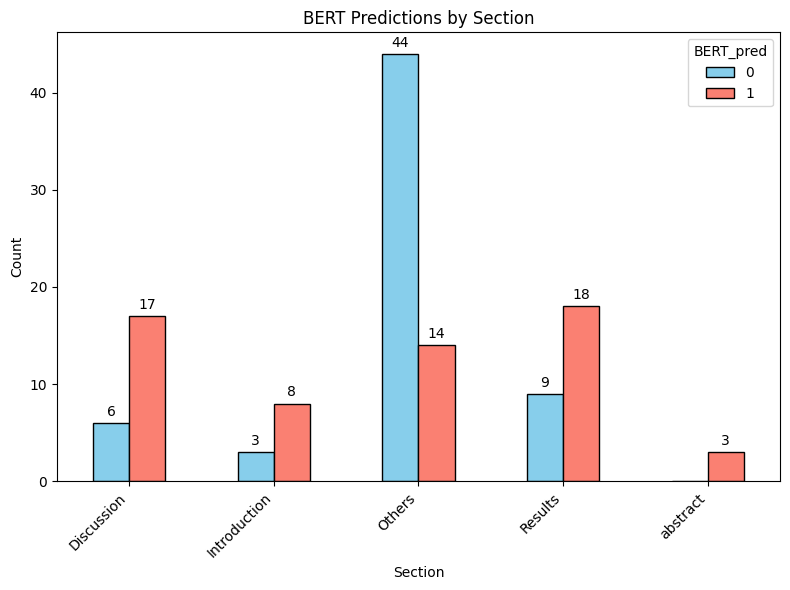

In [12]:
# visulize the filtering decision per section

counts = final_df.groupby(["section", "BERT_pred"]).size().unstack(fill_value=0)

# Plot
ax = counts.plot(
    kind="bar",
    stacked=False,
    figsize=(8,6),
    color={0:"skyblue", 1:"salmon"},
    edgecolor="black"   # outline
)

# Add numbers on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(
            str(height),
            (p.get_x() + p.get_width()/2., height),
            ha='center', va='bottom',
            fontsize=10, color="black", xytext=(0,3),
            textcoords="offset points"
        )

plt.xlabel("Section")
plt.ylabel("Count")
plt.title("BERT Predictions by Section")
plt.xticks(rotation=45, ha="right")
plt.legend(title="BERT_pred")
plt.tight_layout()
plt.show()


### 1.1without filter

In [13]:
final_df['BERT_pred'].value_counts()

BERT_pred
0    62
1    60
Name: count, dtype: int64

In [14]:
# define the column names for the parsed variants, this is the column name for SNV type
col_names = ['PMCID', 'section', 'gene', 'DNA mutation', 'protein mutation', 
             'disease', 'phenotype', 'LLM reasoning', 'pathogenicity']

In [15]:
# run LLM
all_inputs=list(final_df['paragraph'])
final_inputs = generate_prompt(all_inputs,chosen_prompt)
pmc_ids_for_inputs=list(final_df['PMCID'])
sec_for_inputs=list(final_df['section'])

print("Running inference ...")
# Run inference on all inputs
sampling_params = SamplingParams(temperature=0.6, top_p=0.3, max_tokens=1000) 
output = model.generate(final_inputs, sampling_params)

# Convert inference results to a single DataFrame
df_nofilter = inference_to_df(output, pmc_ids_for_inputs, sec_for_inputs, col_names)

Running inference ...


Processed prompts: 100%|██████████| 122/122 [00:45<00:00,  2.70it/s, est. speed input: 1671.24 toks/s, output: 149.03 toks/s]


In [16]:
df_nofilter

,PMCID,section,gene,DNA mutation,protein mutation,disease,phenotype,LLM reasoning,pathogenicity
0,PMC13044143,abstract,CYBA,c.427C>T,p.Q143*,autosomal recessive chronic granulomatous dise...,recurrent severe pneumonia and pleural effusion,assessed as a likely pathogenic variant (PVS1_...,likely pathogenic
1,PMC13044143,Results,CYBA,c.427C>T,p.Q143*,chronic granulomatous disease type 4,-,assessed as a likely pathogenic variant (PVS1_...,likely pathogenic
2,PMC13044143,Introduction,CYBB,-,-,Chronic granulomatous disease (CGD),"phagocyte dysfunction, recurrent severe bacter...",defects in genes encoding the phagocyte Nicoti...,pathogenic
3,PMC13044143,Introduction,CYBA,-,-,Chronic granulomatous disease (CGD),"phagocyte dysfunction, recurrent severe bacter...",defects in genes encoding the phagocyte Nicoti...,pathogenic
4,PMC13044143,Introduction,NCF1,-,-,Chronic granulomatous disease (CGD),"phagocyte dysfunction, recurrent severe bacter...",defects in genes encoding the phagocyte Nicoti...,pathogenic
...,...,...,...,...,...,...,...,...,...
128,PMC12858432,Others,AP4M1,c.258delG,-,-,"altered binding patterns, disrupted or shifted...","altered binding patterns, disrupted or shifted...",likely pathogenic
129,PMC12858432,Others,AP4M1,c.258delG,p.A87Pfs*44,AP4M1-related SPG50,"intellectual disability, hyperintensity in dee...",frameshift variant leading to a premature stop...,pathogenic
130,PMC12858432,Others,AP4M1,c.258delG,p.A87Pfs*44,SPG50 disease,"intellectual disability, seizures, muscle weak...",substantial loss of protein function,pathogenic
131,PMC12858432,Others,,-,-,-,-,-,unknown


### 1.2 with BERT filter

In [17]:
final_df_filtered = final_df[final_df['BERT_pred']==1]

In [18]:
# run LLM
all_inputs=list(final_df_filtered['paragraph'])
final_inputs = generate_prompt(all_inputs,chosen_prompt)
pmc_ids_for_inputs=list(final_df_filtered['PMCID'])
sec_for_inputs=list(final_df_filtered['section'])

print("Running inference ...")
# Run inference on all inputs
sampling_params = SamplingParams(temperature=0.6, top_p=0.3, max_tokens=1000) 
output = model.generate(final_inputs, sampling_params)

# Convert inference results to a single DataFrame
df_filtered = inference_to_df(output, pmc_ids_for_inputs, sec_for_inputs, col_names)

Running inference ...


Processed prompts: 100%|██████████| 60/60 [00:27<00:00,  2.17it/s, est. speed input: 1413.13 toks/s, output: 130.01 toks/s]


In [19]:
df_filtered

,PMCID,section,gene,DNA mutation,protein mutation,disease,phenotype,LLM reasoning,pathogenicity
0,PMC13044143,abstract,CYBA,c.427C>T,p.Q143*,autosomal recessive chronic granulomatous dise...,recurrent severe pneumonia and pleural effusion,assessed as a likely pathogenic variant (PVS1_...,likely pathogenic
1,PMC13044143,Results,CYBA,c.427C>T,p.Q143*,chronic granulomatous disease type 4,-,assessed as a likely pathogenic variant (PVS1_...,likely pathogenic
2,PMC13044143,Introduction,CYBB,-,-,Chronic granulomatous disease (CGD),"phagocyte dysfunction, recurrent severe bacter...",defects in genes encoding the phagocyte NADPH ...,pathogenic
3,PMC13044143,Introduction,CYBA,-,-,Chronic granulomatous disease (CGD),"phagocyte dysfunction, recurrent severe bacter...",defects in genes encoding the phagocyte NADPH ...,pathogenic
4,PMC13044143,Introduction,NCF1,-,-,Chronic granulomatous disease (CGD),"phagocyte dysfunction, recurrent severe bacter...",defects in genes encoding the phagocyte NADPH ...,pathogenic
...,...,...,...,...,...,...,...,...,...
71,PMC12858432,Others,AP4M1,-,-,-,impaired structural integrity and reduced func...,"decrease in protein stability, substantial pro...",pathogenic
72,PMC12858432,Others,AP4M1,c.258delG,-,-,frameshift and premature stop codon,frameshift and premature stop codon,pathogenic
73,PMC12858432,Others,AP4M1,c.258delG,-,-,improper binding,disrupt function and disrupt additional biolog...,likely pathogenic
74,PMC12858432,Others,AP4M1,c.258delG,p.A87Pfs*44,AP4M1-related SPG50,"intellectual disability, hyperintensity in dee...",frameshift variant leading to a premature stop...,pathogenic


# 2.Full-text vs. Per-paragraph Study

### 2.1 fulltext - no flitering

In [43]:
whole_paper_df = final_df.groupby('PMCID')['paragraph'].agg('\n'.join).reset_index()

In [59]:
whole_paper_df['section']='full_text'

In [60]:
whole_paper_df

,PMCID,paragraph,section
0,PMC12858432,Spastic paraplegia 50 (SPG50) is a rare autoso...,full_text
1,PMC12992144,Heterozygous pathogenic variants in ATP2B1 (en...,full_text
2,PMC13044143,Objective To investigate the etiology of recur...,full_text


In [51]:
# run LLM
all_inputs=list(whole_paper_df['paragraph'])
final_inputs = generate_prompt(all_inputs,chosen_prompt)
pmc_ids_for_inputs=list(whole_paper_df['PMCID'])
sec_for_inputs=list(whole_paper_df['section'])

print("Running inference ...")
# Run inference on all inputs
sampling_params = SamplingParams(temperature=0.6, top_p=0.3, max_tokens=1000) 
output = model.generate(final_inputs, sampling_params)

# Convert inference results to a single DataFrame
df_whole_paper_out = inference_to_df(output, pmc_ids_for_inputs, sec_for_inputs, col_names)

Running inference ...


Processed prompts: 100%|██████████| 3/3 [00:46<00:00, 15.64s/it, est. speed input: 449.99 toks/s, output: 41.34 toks/s]


In [52]:
df_whole_paper_out

,PMCID,section,gene,DNA mutation,protein mutation,disease,phenotype,LLM reasoning,pathogenicity
0,PMC12858432,full_text,AP4M1,c.258delG,p.A87Pfs*44,Spastic paraplegia 50 (SPG50),"intellectual disability, seizures, muscle weak...",loss of protein function due to premature term...,pathogenic
1,PMC12992144,full_text,"""",None,None,None,None,None,None
21,PMC12992144,full_text,,None,None,None,None,None,None
22,PMC12992144,full_text,ATP-type ATP2B1.,None,None,None,None,None,None
28,PMC12992144,full_text,ATP-type ATP2B1,None,None,None,None,None,None
32,PMC12992144,full_text,"ATP-type ATP2.""",None,None,None,None,None,None
407,PMC13044143,full_text,CYBA,c.427C>T,p.Q143*,"Chronic granulomatous disease (CGD), Autosomal...","Recurrent severe infections, phagocyte dysfunc...",Loss of the proline-rich C-terminal domain of ...,likely
408,PMC13044143,full_text,CYBA,likely pathogenic variant c.,None,None,None,None,None
409,PMC13044143,full_text,CYBA,"loss of Intron, autosomal immunodeficiency",likely pathogenic variant site,None,None,None,None


### fulltext - filter and concate

In [53]:
whole_paper_df_filtered = final_df_filtered.groupby('PMCID')['paragraph'].agg('\n'.join).reset_index()

In [58]:
whole_paper_df_filtered['section']='full_text_filtered'

In [61]:
whole_paper_df_filtered

,PMCID,paragraph,section
0,PMC12858432,Spastic paraplegia 50 (SPG50) is a rare autoso...,full_text_filtered
1,PMC12992144,Heterozygous pathogenic variants in ATP2B1 (en...,full_text_filtered
2,PMC13044143,Objective To investigate the etiology of recur...,full_text_filtered


In [65]:
whole_paper_df_filtered['words']=whole_paper_df_filtered['paragraph'].str.count(' ') + 1

In [66]:
whole_paper_df_filtered

,PMCID,paragraph,section,words
0,PMC12858432,Spastic paraplegia 50 (SPG50) is a rare autoso...,full_text_filtered,1873
1,PMC12992144,Heterozygous pathogenic variants in ATP2B1 (en...,full_text_filtered,2467
2,PMC13044143,Objective To investigate the etiology of recur...,full_text_filtered,2874


In [62]:
# run LLM
all_inputs=list(whole_paper_df_filtered['paragraph'])
final_inputs = generate_prompt(all_inputs,chosen_prompt)
pmc_ids_for_inputs=list(whole_paper_df_filtered['PMCID'])
sec_for_inputs=list(whole_paper_df_filtered['section'])

print("Running inference ...")
# Run inference on all inputs
sampling_params = SamplingParams(temperature=0.6, top_p=0.3, max_tokens=1000) 
output = model.generate(final_inputs, sampling_params)

# Convert inference results to a single DataFrame
df_whole_paper_filtered_out = inference_to_df(output, pmc_ids_for_inputs, sec_for_inputs, col_names)

Running inference ...


Processed prompts: 100%|██████████| 3/3 [00:08<00:00,  2.91s/it, est. speed input: 1495.70 toks/s, output: 28.22 toks/s]


In [63]:
df_whole_paper_filtered_out

,PMCID,section,gene,DNA mutation,protein mutation,disease,phenotype,LLM reasoning,pathogenicity
0,PMC12858432,full_text_filtered,AP4M1,c.258delG,p.A87Pfs*44,Spastic paraplegia 50 (SPG50),"intellectual disability, seizures, muscle weak...",loss of protein function due to premature term...,pathogenic
1,PMC12992144,full_text_filtered,ATP2B1,c.2140A>C,p.Thr714Pro,autosomal dominant intellectual developmental ...,"global developmental delay, infantile spasms, ...",defective plasma membrane trafficking and intr...,likely pathogenic
2,PMC13044143,full_text_filtered,CYBA,c.427C>T,p.Q143*,chronic granulomatous disease type 4 (CGD),recurrent severe pneumonia and pleural effusion,nonsense mutation introducing a premature stop...,likely pathogenic


# 3.Normalization (Necessary Component)

### 3.1 quality filtering

In [20]:
from intervaltree import IntervalTree
import pyensembl
from Bio.Seq import Seq
from Bio import pairwise2, SeqIO
from pyensembl import EnsemblRelease

/home/wangp5/miniconda3/envs/vllm/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [21]:
data = EnsemblRelease(release=111, species='homo_sapiens')
gene_names = data.gene_names()
gene_names = [gene for gene in gene_names if gene !='']


In [23]:
df=df_nofilter

In [24]:
# filter out the gene name that is not human gene
df = df[df['gene'].isin(gene_names)]
df=df[(df['DNA mutation']!='-') | (df['protein mutation']!='-')]

In [67]:
# filter out the pathogenicity assiganment that is not within the predefined categories (in prompt)
df["pathogenicity"] = df["pathogenicity"].replace("-", "unknown")
# refine patho classification
valid_patho = ['pathogenic', 'likely pathogenic', 'conflicting', 'likely benign', 'benign', 'unknown']
df = df[df['pathogenicity'].isin(valid_patho)]

### 3.2 variant_parser (regex)

In [68]:
import re

In [69]:
# Dictionary to convert one-letter to three-letter amino acid codes
aa_dict = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val',
    '*': 'Ter'  # Stop codon
    
}

def parse_protein_variant(variant):
    """Parse protein variant and return (position, from_aa, to_aa)"""
    if not isinstance(variant, str) or variant in ["-", ""]:
        return None, None, None

    # Normalize input
    variant = variant.replace("p.", "").replace("P.", "")
    variant = variant.replace("Ter", "*").replace("sp", "*").replace("stop", "*")
    variant = variant.replace("DEL", "del").replace("Del", "del").replace("INS", "ins").replace("Ins", "ins")

    patterns = [
        # 3-letter substitution + frameshift + *
        (r"([A-Za-z]{3})(\d+)([A-Za-z]{3})fs\*(\d+)", lambda m: (m[1], aa_dict.get(m[0], m[0]), f"{m[2]}fs*{m[3]}")),
        # 3-letter substitution
        (r"\b([A-Za-z]{3})(\d+)([A-Za-z]{3})\b", lambda m: (m[1], m[0], m[2])),
        # 1-letter substitution
        (r"\b([A-Z])(\d+)([A-Z])\b", lambda m: (m[1], aa_dict.get(m[0], m[0]), aa_dict.get(m[2], m[2]))),
        # frameshift + stop
        (r"([A-Za-z]{3})(\d+)fs\*(\d+)", lambda m: (m[1], aa_dict.get(m[0], m[0]), f"fs*{m[2]}")),
        (r"([A-Z])(\d+)fs\*(\d+)", lambda m: (m[1], aa_dict.get(m[0], m[0]), f"fs*{m[2]}")),
        # frameshift + no stop
        (r"([A-Za-z]{3})(\d+)fs\*", lambda m: (m[1], aa_dict.get(m[0], m[0]), "fs*")),
        (r"([A-Z])(\d+)fs\*", lambda m: (m[1], aa_dict.get(m[0], m[0]), "fs*")),
        # simple frameshift
        (r"\b([A-Za-z]{3})(\d+)fs\b", lambda m: (m[1], aa_dict.get(m[0], m[0]), "fs")),
        (r"\b([A-Z])(\d+)fs\b", lambda m: (m[1], aa_dict.get(m[0], m[0]), "fs")),
        # deletion
        (r"\b([A-Za-z]{3})(\d+)del\b", lambda m: (m[1], aa_dict.get(m[0], m[0]), "del")),
        (r"\b([A-Z])(\d+)del\b", lambda m: (m[1], aa_dict.get(m[0], m[0]), "del")),
        # termination
        (r"([A-Za-z]{3})(\d+)\*", lambda m: (m[1], aa_dict.get(m[0], m[0]), "Ter")),
        (r"([A-Z])(\d+)\*", lambda m: (m[1], aa_dict.get(m[0], m[0]), "Ter")),
        # insertion
        (r"\b(\d+)ins([A-Z])\b", lambda m: (m[0], "ins", aa_dict.get(m[1], m[1]))),
        (r"\b(\d+)ins([A-Za-z]{3})\b", lambda m: (m[0], "ins", aa_dict.get(m[1], m[1])))
    ]

    for pattern, handler in patterns:
        match = re.search(pattern, variant)
        if match:
            return handler(match.groups())

    return None, None, None


def parse_dna_variant(variant):
    """Return (pos, from, to, rsid) from a DNA/cDNA mutation string."""
    if not isinstance(variant, str) or variant.strip() in ["-", ""]:
        return None, None, None, None

    variant = re.sub(r"\s+", "", variant) #removes all whitespace characters
    variant = variant.replace("→", ">").replace("c.", "").replace("C.", "").replace("g.", "").replace("G.", "")

    patterns = [
        (r"\b([\d\+]+)([ATGC]+)[-/]*[>/]([ATGC]+)\b", lambda m: (m[0], m[1], m[2], None)),
        (r"\b(\d+)([ATGC]+)[-/]*[>/]([ATGC]+)\b", lambda m: (m[0], m[1], m[2], None)),
        (r"\b([ATGC]+)(\d+)([ATGC]+)\b", lambda m: (m[1], m[0], m[2], None)),
        (r"\b(\d+)del([ATGC]*)\b", lambda m: (m[0], m[1] if m[1] else "-", "del", None)),
        (r"\bdel(\d+)([ATGC]*)\b", lambda m: (m[0], m[1] if m[1] else "-", "del", None)),
        (r"\b(\d+_\d+)del([ATGC]*)\b", lambda m: (m[0], m[1] if m[1] else "-", "del", None)),
        (r"\b([\d_]+)ins([ATGC]+)\b", lambda m: (m[0], "ins", m[1], None)),
        (r"\bins([\d_]+)([ATGC]+)\b", lambda m: (m[0], "ins", m[1], None)),
        (r"\b([\d_]+)dup([ATGC]+)\b", lambda m: (m[0], "dup", m[1], None)),
        (r"\bdup([\d_]+)([ATGC]+)\b", lambda m: (m[0], "dup", m[1], None)),
        (r"\b(rs\d+)([ATGC]+)[-/]*[>/]([ATGC]+)\b", lambda m: (None, m[1], m[2], m[0])),
        (r"\b(rs\d+)\b", lambda m: (None, None, None, m[0]))
    ]

    for pattern, handler in patterns:
        match = re.search(pattern, variant, re.IGNORECASE)
        if match:
            #turn result into upper case
            groups_upper = tuple(g.upper() if isinstance(g, str) and g.upper() in ['A','T','C','G'] else g for g in match.groups())
            return handler(groups_upper)

    return None, None, None, None



# Evaluate
###############Protein############
lst_of_test = ['p.Lys1129Ter','p.Lys1129*','P.p.Lys1129Ter',
               'p.(lys121arg)','Lys121arg','Lys121Arg',
               'A21*','T32Ter','T342sp','K32stop',
               'A12K','K32N',
               'A21del','Lys32del','K3DEL',
               '21insA','32insLys','3INSK',
               'A21fs','Lys32fs',
               'A21fs*','Lys32fs*','A21fs*21','Lys32fs*31',
               '(Pro588Argfs*18)'
              ]

lst_of_test_results = ['Lys1129Ter','Lys1129Ter','Lys1129Ter',
               'lys121arg','Lys121arg','Lys121Arg',
               'Ala21Ter','Thr32Ter','Thr342Ter','Lys32Ter',
               'Ala12Lys','Lys32Asn',
               'Ala21del','Lys32del','Lys3del',
               'ins21Ala','ins32Lys','ins3Lys',
               'Ala21fs','Lys32fs',
               'Ala21fs*','Lys32fs*','Ala21fs*21','Lys32fs*31',
               'Pro588Argfs*18'
              ]

results = []
for i, test_str in enumerate(lst_of_test):
    parsed = parse_protein_variant(test_str)
    try:
        if not parsed[0] or not parsed[1] or not parsed[2]:
            result_str = "None"
        elif parsed[1] == "ins":
            result_str = f"ins{parsed[0]}{parsed[2]}"
        else:
            result_str = f"{parsed[1]}{parsed[0]}{parsed[2]}"
        results.append((test_str, result_str, lst_of_test_results[i],result_str == lst_of_test_results[i]))
    except Exception as e:
        results.append((test_str, f"ERROR: {e}", False))

if len([re for re in results if not re[3]])==0:
    print("Pass all tests!")
else:
    print("Failed cases:")
    print([re for re in results if not re[3]])
    

###########cDNA###########
# Example test cases and expected results
test_variants = [
    "c.123A>G", "c.(123A>G)","G123A", "123delA", "del123T",
    "c.201 + 1G > T", "c.201+1g > t",
    "123_456del", "123insA", "ins123C",
    "123dupT", "dup123G", "rs123", "RS1029524",
    "rs456C>T", "g.456T>G", "  321  A  >  T"
]
expected_outputs = [
    ("123", "A", "G", None), ("123", "A", "G", None), ("123", "G", "A", None), ("123", "A", "del", None), ("123", "T", "del", None),
    ("201+1","G","T",None),("201+1","G","T",None),
    ("123_456", "-", "del", None), ("123", "ins", "A", None), ("123", "ins", "C", None),
    ("123", "dup", "T", None), ("123", "dup", "G", None), (None, None, None, "rs123"),(None, None, None, "RS1029524"),
    (None, "C", "T", "rs456"), ("456", "T", "G", None), ("321", "A", "T", None)
]

# Evaluate function
results = []
for var, expected in zip(test_variants, expected_outputs):
    try:
        parsed = parse_dna_variant(var)
        results.append((var, parsed, expected,parsed == expected))
    except Exception as e:
        results.append((var, f"ERROR: {e}", False))

if len([re for re in results if not re[3]])==0:
    print("Pass all tests!")
else:
    print("Failed cases:")
    print([re for re in results if not re[3]])  


Pass all tests!
Pass all tests!


In [70]:
%%time
# Apply functions to extract normalized variant representation
df[['dna_pos', 'dna_from', 'dna_to', 'RSID']] = df['DNA mutation'].apply(lambda x: pd.Series(parse_dna_variant(x)))
df[['aa_pos', 'aa_from', 'aa_to']] = df['protein mutation'].apply(lambda x: pd.Series(parse_protein_variant(x)))
df['dna_change']=df['dna_from']+df['dna_pos']+df['dna_to']
df['aa_change']=df['aa_from']+df['aa_pos']+df['aa_to']



CPU times: user 9.94 ms, sys: 1.11 ms, total: 11 ms
Wall time: 12 ms


### 3.3 map to transcripts

In [72]:
import pandas as pd
from pyensembl import EnsemblRelease
from Bio.Seq import Seq
import numpy as np
import logging
logging.getLogger("pyensembl.sequence_data").setLevel(logging.ERROR)


In [73]:
# Initialize Ensembl reference (GRCh38, release 111)
ensembl = EnsemblRelease(111, species='homo_sapiens')

aa_dict = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val',
    '*': 'Ter'  # Stop codon
}

def get_cds_genomic_positions(tx):
    ranges = tx.coding_sequence_position_ranges
    genomic_positions = []
    for start, end in ranges:
        if tx.strand == "+":
            genomic_positions.extend(range(start, end + 1))
        else:
            # Reverse direction for minus strand
            genomic_positions.extend(range(end, start - 1, -1))
    return genomic_positions


def protein_to_genomic(gene_name, aa_pos, aa_ref=None):
    try:
        #print(len(ensembl.genes_by_name(gene_name)))
        genes = ensembl.genes_by_name(gene_name)
    except ValueError:
        #print(f'gene {gene_name} not found')
        return None  # Gene not found
    
    all_match_tx = []
    for gene in genes:
        for tx in gene.transcripts:
            if tx.is_protein_coding:
                try:
                    cds = tx.coding_sequence
                    aa_seq = Seq(cds).translate()

                    if aa_pos <= len(aa_seq):
                        aa_from_aa_seq = aa_dict.get(aa_seq[aa_pos - 1])
                        if aa_ref:
                            
                            #check if the provided aa same as ref aa based on pos
                            if aa_ref!=aa_from_aa_seq:
                                #print('ref aa not match')
                                continue
                                
                        codon_start = (aa_pos - 1) * 3

                        # Get full CDS genomic position map
                        cds_genome = get_cds_genomic_positions(tx)

                        # get genome coodirnate based on codon_start
                        codon_coords = cds_genome[codon_start:codon_start+3]
                        # get cDNA codon
                        codon = cds[codon_start:codon_start + 3]
                        # get genome ref
                        if tx.strand=='+':
                            genome_codon = codon
                        else:
                            genome_codon = str(Seq(codon).reverse_complement())

                        all_match_tx.append({
                            "transcript_id": tx.transcript_id,
                            "chromosome": tx.contig,
                            "strand": tx.strand,
                            "genomic_coords": codon_coords,
                            "ref_aa": aa_seq[aa_pos - 1],
                            "codon_cDNA": codon,
                            'gnomic_codon': genome_codon
                        })
                        
                    #else:
                        #print('ref tx is too short')
                except Exception:
                    continue
    if len(all_match_tx) == 0:
        return None
    return all_match_tx


def cdna_to_genomic(gene_name, cdna_pos, ref_nt=None):
    try:
        genes = ensembl.genes_by_name(gene_name)
    except ValueError:
        #print(f'Gene {gene_name} not found')
        return None

    matches = []

    for gene in genes:
        for tx in gene.transcripts:
            if tx.is_protein_coding:
                try:
                    # Get spliced transcript (cDNA sequence)
                    cdna_seq = tx.coding_sequence
                    if cdna_pos > len(cdna_seq):
                        continue
                    
                    nt_from_tx = cdna_seq[cdna_pos - 1]  # 1-based to 0-based
                    
                    # Optional: check ref nucleotide match
                    if ref_nt:
                        if nt_from_tx.upper() != ref_nt.upper():
                            continue

                    # Use spliced offset for genomic mapping
                    cds_genome = get_cds_genomic_positions(tx)
                    
                    genome_coord = cds_genome[cdna_pos - 1]
                    
                    # get genome ref
                    if tx.strand=='+':
                        genome_ref = nt_from_tx
                    else:
                        genome_ref = str(Seq(nt_from_tx).complement())
                        
                    matches.append({
                        "transcript_id": tx.transcript_id,
                        "chromosome": tx.contig,
                        "strand": tx.strand,
                        "genomic_coord": genome_coord,
                        "ref_cDNA": nt_from_tx,
                        "genomic_ref": genome_ref
                    })
                except Exception as e:
                    continue
    if len(matches) == 0:
        return None
    return matches

def annotate_row(row):
    gene = row['gene']

    if gene=='-' or gene=='nan' or gene==np.nan:
        return None
    
    # Use cDNA info first
    if pd.notnull(row.get('dna_pos')) and pd.notnull(row.get('dna_from')):
        try:
            cdna_coord = cdna_to_genomic(gene, int(row['dna_pos']), row['dna_from'])
            if cdna_coord!=None:
                return cdna_coord
           
        except Exception as e:
            return f'cdna_error: {e}'
        
    # Use protein info if available
    elif pd.notnull(row.get('aa_pos')) and pd.notnull(row.get('aa_from')):
        try:
            return protein_to_genomic(gene, int(row['aa_pos']), row['aa_from'])
        except Exception as e:
            return f'protein_error: {e}'
    
    
    
    return None




In [74]:
%%time
df['genomic_coord_result'] = df.apply(annotate_row,axis=1)

CPU times: user 353 ms, sys: 491 ms, total: 844 ms
Wall time: 2.8 s


### 3.4 map to genome coordiantes

In [75]:
import pandas as pd
import ast
from Bio.Seq import Seq
from Bio.Data import CodonTable

In [76]:
# 3-letter to 1-letter amino acid dictionary
aa_dict = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val',
    '*': 'Ter'
}
aa_3to1 = {v: k for k, v in aa_dict.items()}

# Amino acid to RNA codon table
standard_table = CodonTable.unambiguous_rna_by_name["Standard"]
aa_to_codons = {}
for codon, aa in standard_table.forward_table.items():
    aa_to_codons.setdefault(aa, []).append(codon)
for codon in standard_table.stop_codons:
    aa_to_codons.setdefault("*", []).append(codon)


def get_cdna_variant(tx, dna_pos, dna_from, dna_to):
    if 'ref_cDNA' not in tx or 'genomic_coord' not in tx:
        return None

    if str(tx['ref_cDNA']).upper() != str(dna_from).upper():
        return None

    pos = tx['genomic_coord']
    ref = str(dna_from).upper()
    alt = str(dna_to).upper()

    # Adjust for strand
    if tx['strand'] == '-':
        ref = str(Seq(ref).complement())
        alt = str(Seq(alt).complement())

    return {
        'chr': tx['chromosome'],
        'pos': pos,
        'ref': ref,
        'alt': alt,
        'transcript_id': tx['transcript_id']
    }

    
    
def get_protein_variant(tx, aa_pos, aa_from, aa_to):
    if 'ref_aa' not in tx or 'genomic_coords' not in tx or 'gnomic_codon' not in tx:
        return []

    # Convert 3-letter to 1-letter amino acid
    aa_from_1 = aa_3to1.get(str(aa_from).capitalize())
    aa_to_1 = aa_3to1.get(str(aa_to).capitalize())
    if not aa_from_1 or not aa_to_1:
        return []

    if tx['ref_aa'].upper() != aa_from_1:
        return []

    ref_codon = tx['gnomic_codon'].upper()
    strand = tx['strand']
    coords = tx['genomic_coords']
    variants = []

    for alt_rna_codon in aa_to_codons.get(aa_to_1, []):
        # Convert RNA to DNA
        alt_dna_codon = alt_rna_codon.replace("U", "T")

        if strand == '+':
            alt_genomic_codon = alt_dna_codon
            start_coord = coords[0]
        else:
            alt_genomic_codon = str(Seq(alt_dna_codon).reverse_complement())
            start_coord = coords[-1]

        if ref_codon != alt_genomic_codon:
            variants.append({
                'chr': tx['chromosome'],
                'pos': start_coord,  # always the leftmost genomic position
                'ref': ref_codon,
                'alt': alt_genomic_codon,
                'transcript_id': tx['transcript_id'],
                'aa_from': aa_from,
                'aa_to': aa_to
            })

    return variants


def parse_variant_from_transcript(row, mane_tx_dict):
    gene = row['gene']
    results = []
    if row['genomic_coord_result']==None:
        return results
    
    try:
        if isinstance(row['genomic_coord_result'], str):
            if row['genomic_coord_result'].strip().startswith("[{"):
                transcripts = ast.literal_eval(row['genomic_coord_result'])
            else:
                return []  
        else:
            transcripts = row['genomic_coord_result']
    except Exception:
        return [] 
        
    # Extract variant information
    dna_pos = row.get('dna_pos')
    dna_from = row.get('dna_from')
    dna_to   = row.get('dna_to')
    aa_pos   = row.get('aa_pos')
    aa_from  = row.get('aa_from')
    aa_to    = row.get('aa_to')

    mane_tx = mane_tx_dict.get(gene)
    

    for tx in transcripts:
        is_mane = (tx['transcript_id'] == mane_tx)

        if 'ref_aa' in tx and pd.notnull(aa_pos) and pd.notnull(aa_from) and pd.notnull(aa_to):
            variants = get_protein_variant(tx, aa_pos, aa_from, aa_to)
        elif 'ref_cDNA' in tx and pd.notnull(dna_pos) and pd.notnull(dna_from) and pd.notnull(dna_to):
            variant = get_cdna_variant(tx, dna_pos, dna_from, dna_to)
            variants = [variant] if variant else []
        else:
            continue

        for var in variants:
            if var:
                var_clean = {
                    'chr': var['chr'],
                    'pos': var['pos'],
                    'ref': var['ref'],
                    'alt': var['alt'],
                    'MANE_transcript_used': str(is_mane)
                }
                results.append(var_clean)

    # Deduplicate by chr, pos, ref, alt
    seen = set()
    unique_results = []
    for r in results:
        key = (r['chr'], r['pos'], r['ref'], r['alt'])
        if key not in seen:
            seen.add(key)
            unique_results.append(r)

    return unique_results if unique_results else None



In [78]:
# load MANE select transcipt
mane_select = pd.read_csv('../example/mane.bed',sep='\t',header=None)
mane_select['ENST']=mane_select[3].apply(lambda x: x.split('.')[0])
mane_tx_df = mane_select[[18,'ENST']].rename(columns={18:'gene'})
mane_tx_dict = dict(zip(mane_tx_df['gene'], mane_tx_df['ENST']))

In [79]:
%%time
df['parsed_variants'] = df.apply(lambda row:parse_variant_from_transcript(row, mane_tx_dict), axis=1)


CPU times: user 3.7 ms, sys: 49 μs, total: 3.75 ms
Wall time: 4.72 ms


### 3.5 disease/phenotype normalization

In [80]:
from sentence_transformers import SentenceTransformer, util
from difflib import SequenceMatcher
import numpy as np

INFO:datasets:PyTorch version 2.4.0 available.
INFO:datasets:Polars version 0.20.31 available.


In [81]:
mondo_df = pd.read_csv('../example/MONDO_id_name.tsv',sep='\t',header=0)
mondo_dx_lst = list(mondo_df['MONDO name'])

In [82]:
# load the PubMedBERT model for disease/phenotype name embedding
emb_model = SentenceTransformer('neuml/pubmedbert-base-embeddings')
features_embeddings = emb_model.encode(mondo_dx_lst, convert_to_tensor=True)


INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cuda
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: neuml/pubmedbert-base-embeddings


Batches:   0%|          | 0/939 [00:00<?, ?it/s]

In [83]:
def text_similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()  # Ratio between 0 and 1

def find_similarity_emb(entity, graph_features_nodes,features_embeddings, emb_model = emb_model, threshold = 0.9):
    # Compute embeddings for the entity and graph_nodes
    if type(entity)!=str:
        return ()
    
    entity = entity.lower()

    entity_embedding = emb_model.encode(entity, convert_to_tensor=True)
    # Compute cosine similarities
    similarities = util.cos_sim(entity_embedding, features_embeddings).squeeze(0)
    # Filter graph_nodes by similarity threshold
    similar_terms =  [(node,sim) for node, sim in zip(graph_features_nodes, similarities) if sim >= threshold]#,
    if len(similar_terms) == 0:
        similar_terms =  [(node,sim) for node, sim in zip(graph_features_nodes, similarities) if sim >= threshold-0.05]#,

    semantic_scores = np.array([sim.cpu().item() for _, sim in similar_terms])  # Move to CPU and convert to NumPy array
    text_similarities = np.array([text_similarity(entity, term) for term, _ in similar_terms])

    # Weighted combination of scores
    alpha = 0.75  # Adjust to control balance
    final_scores = alpha * semantic_scores + (1 - alpha) * text_similarities  # Vectorized computation

    # Sort indices based on final scores in descending order
    sorted_indices = np.argsort(final_scores)[::-1]

    # Extract sorted results
    sorted_terms = [(similar_terms[i][0], semantic_scores[i], text_similarities[i], final_scores[i]) for i in sorted_indices]
    if len(sorted_terms) > 0:
        return sorted_terms[0] #only return the highest term
    else:
        return ()

In [84]:
# perform disease normalization
dx_llm_mondo_dict = {}
for dx in df['disease'].unique():
    dx_llm_mondo_dict[dx]=find_similarity_emb(dx,mondo_dx_lst,features_embeddings,emb_model,0)

print('Finish disease normalization')

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Finish disease normalization


In [85]:
df_lst=[[k,v[0],v[1],v[2],v[3]] if len(v)!=0 else [k,None,np.nan,np.nan,np.nan] for k,v in dx_llm_mondo_dict.items() ]
df_norm = pd.DataFrame(df_lst,columns=['disease','MONDO name','disease pbmbert sim','disease string sim','disease combine sim'])
df_norm_merge = df_norm.merge(mondo_df,on='MONDO name',how='left')

In [86]:
df_mondo = df.merge(df_norm_merge,on='disease',how='left')

In [87]:
hpo_df = pd.read_csv('../example/HPO_id_term.tsv',header=0,sep='\t')

hpo_id_lst = list(hpo_df['HPO term'])

emb_model = SentenceTransformer('neuml/pubmedbert-base-embeddings') ## Change your embedding model here
features_embeddings = emb_model.encode(hpo_id_lst, convert_to_tensor=True)


INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cuda
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: neuml/pubmedbert-base-embeddings


Batches:   0%|          | 0/611 [00:00<?, ?it/s]

In [88]:
# perform phenotype normalization
phe_llm_hpo_dict = {}
for phe in df['phenotype'].unique():
    phe_llm_hpo_dict[phe]=find_similarity_emb(phe,hpo_id_lst,features_embeddings,emb_model,0)

print('Finish phenotype normalization')

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Finish phenotype normalization


In [89]:
df_lst=[[k,v[0],v[1],v[2],v[3]] if len(v)!=0 else [k,None,np.nan,np.nan,np.nan] for k,v in phe_llm_hpo_dict.items() ]
df_norm = pd.DataFrame(df_lst,columns=['phenotype','HPO term','phenotype pbmbert sim','phenotype string sim','phenotype combine sim'])
df_norm_merge = df_norm.merge(hpo_df,on='HPO term',how='left')

In [90]:
df_mondo_hpo = df_mondo.merge(df_norm_merge,on='phenotype',how='left')

In [109]:
df_mondo_hpo.head()

,PMCID,section,gene,DNA mutation,protein mutation,disease,phenotype,LLM reasoning,pathogenicity,dna_pos,...,MONDO name,MONDO_pubmedbert_sim,MONDO_string_sim,MONDO_combine_sim,MONDO_ID,HPO term,HPO_pubmedbert_sim,HPO_string_sim,HPO_combine_sim,HPO_ID
0,PMC13044143,abstract,CYBA,c.427C>T,p.Q143*,autosomal recessive chronic granulomatous dise...,recurrent severe pneumonia and pleural effusion,assessed as a likely pathogenic variant (PVS1_...,likely pathogenic,427,...,"granulomatous disease, chronic, autosomal rece...",0.822569,0.380165,0.711968,MONDO:0030066,Pleural effusion,0.775765,0.47619,0.700871,HP:0002202
1,PMC13044143,Results,CYBA,c.427C>T,p.Q143*,chronic granulomatous disease type 4,-,assessed as a likely pathogenic variant (PVS1_...,likely pathogenic,427,...,chronic granulomatous disease,0.869929,0.892308,0.875524,MONDO:0018305,All,0.656274,0.00000,0.492206,HP:0000001
2,PMC13044143,Results,CYBA,c.427C>T,p.Q143*,-,-,reliable detection results with high sequencin...,likely pathogenic,427,...,iniencephaly,0.602908,0.000000,0.452181,MONDO:0018968,All,0.656274,0.00000,0.492206,HP:0000001
3,PMC13044143,Results,CYBA,c.427C>T,p.Q143*,-,-,no reports were found for this variant site,unknown,427,...,iniencephaly,0.602908,0.000000,0.452181,MONDO:0018968,All,0.656274,0.00000,0.492206,HP:0000001
4,PMC13044143,Results,CYBA,c.427C>T,p.Q143*,-,-,-,pathogenic,427,...,iniencephaly,0.602908,0.000000,0.452181,MONDO:0018968,All,0.656274,0.00000,0.492206,HP:0000001


In [98]:
df_mondo_hpo.columns

Index(['PMCID', 'section', 'gene', 'DNA mutation', 'protein mutation',
       'disease', 'phenotype', 'LLM reasoning', 'pathogenicity', 'dna_pos',
       'dna_from', 'dna_to', 'RSID', 'aa_pos', 'aa_from', 'aa_to',
       'dna_change', 'aa_change', 'genomic_coord_result', 'parsed_variants',
       'MONDO name', 'disease pbmbert sim', 'disease string sim',
       'disease combine sim', 'MONDO ID', 'HPO term', 'phenotype pbmbert sim',
       'phenotype string sim', 'phenotype combine sim', 'HPO ID'],
      dtype='object')

In [110]:
df_mondo_hpo=df_mondo_hpo.rename(columns={'disease pbmbert sim':'MONDO_pubmedbert_sim',
                                'disease string sim':'MONDO_string_sim',
                                'disease combine sim':'MONDO_combine_sim',
                                'MONDO ID':'MONDO_ID',
                                'MONDO name':'MONDO_name',          
                                'phenotype pbmbert sim':'HPO_pubmedbert_sim',
                                'phenotype string sim':'HPO_string_sim',
                                'phenotype combine sim':'HPO_combine_sim',
                                'HPO ID':'HPO_ID',
                                'HPO term':'HPO_term'          
                               })

# Consolidate variants

In [94]:
import ast
import numpy as np
import re

In [127]:
human_final_df = df_mondo_hpo

In [128]:
human_final_df['MONDO_combine_sim'] = human_final_df['MONDO_combine_sim'].replace('-',np.nan).astype(float)
human_final_df['HPO_combine_sim'] = human_final_df['HPO_combine_sim'].replace('-',np.nan).astype(float)

In [129]:
human_final_df['MONDO_pubmedbert_sim'] = human_final_df['MONDO_pubmedbert_sim'].replace('-',np.nan).astype(float)
human_final_df['HPO_pubmedbert_sim'] = human_final_df['HPO_pubmedbert_sim'].replace('-',np.nan).astype(float)

In [130]:
%%time
human_final_df['MONDO_name_09'] = human_final_df.apply(
    lambda row: row['MONDO_name'] if row['MONDO_pubmedbert_sim'] > 0.9 else np.nan,
    axis=1
)

# Filter HPO term by similarity threshold
human_final_df['HPO_term_09'] = human_final_df.apply(
    lambda row: row['HPO_term'] if row['HPO_pubmedbert_sim'] > 0.9 else np.nan,
    axis=1
)

CPU times: user 1.32 ms, sys: 52 μs, total: 1.37 ms
Wall time: 1.38 ms


In [131]:
def format_reference(row):
    pmcid = row["PMCID"]
    pmid = '.'
    section = row["section"]
    
    if pmcid == "-" or pd.isna(pmcid):
        return f"PMID:{pmid}"
    else:
        if pmid == "-" or pd.isna(pmid):
            return f"{pmcid}:{section}"
        else:
            return f"{pmcid}(PMID:{pmid}):{section}"

# Apply to DataFrame
human_final_df["formatted_reference"] = human_final_df.apply(format_reference, axis=1)


In [132]:
human_final_df=human_final_df.fillna('-')

In [134]:
human_final_df['LLM_mutation'] = human_final_df['DNA mutation'] + ';' + human_final_df['protein mutation']

In [135]:
human_final_df['genomic_coord_result']=human_final_df['genomic_coord_result'].astype(str)
human_final_df['parsed_variants']=human_final_df['parsed_variants'].astype(str)

In [136]:
grouped_df = human_final_df.groupby(["gene", "RSID", "dna_change", "aa_change","genomic_coord_result","parsed_variants"], as_index=False).agg({
    "LLM_mutation": lambda x: " | ".join(x),
    "LLM reasoning": lambda x: " | ".join(x),
    "pathogenicity": lambda x: " | ".join(x),
    "formatted_reference": lambda x: " | ".join(x),
    "MONDO_name_09":  lambda x: " | ".join(x),
    "HPO_term_09":  lambda x: " | ".join(x),
    "disease":  lambda x: " | ".join(x),
    "phenotype":  lambda x: " | ".join(x),
})

# Add the count of records per group
grouped_df["Num_of_record_used"] = human_final_df.groupby(["gene", "RSID", "dna_change", "aa_change"]).size().values

grouped_df

,gene,RSID,dna_change,aa_change,genomic_coord_result,parsed_variants,LLM_mutation,LLM reasoning,pathogenicity,formatted_reference,MONDO_name_09,HPO_term_09,disease,phenotype,Num_of_record_used
0,AP4M1,-,G258del,-,"[{'transcript_id': 'ENST00000713591', 'chromos...","[{'chr': '7', 'pos': 100102867, 'ref': 'G', 'a...",c.258delG;p.A87Pfs*44 | c.258delG;p.A87Pfs*44 ...,"loss of function, disrupts proper intramolecul...",pathogenic | pathogenic | pathogenic | likely ...,PMC12858432(PMID:.):abstract | PMC12858432(PMI...,- | - | - | - | - | - | -,- | - | - | - | - | - | -,Spastic paraplegia 50 (SPG50) | - | - | - | - ...,"intellectual disability, seizures, muscle weak...",7
1,AP4M1,-,G258del,Ala87Profs*44,"[{'transcript_id': 'ENST00000713591', 'chromos...","[{'chr': '7', 'pos': 100102867, 'ref': 'G', 'a...",c.258delG;p.Ala87Profs*44,"premature termination, disruption of protein-p...",pathogenic,PMC12858432(PMID:.):Discussion,-,-,SPG50,-,1
2,ATP2B1,-,-,-,None,[],-;p.Asp239Gly,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1
3,ATP2B1,-,-,Arg763Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89610467, 'ref': 'TCG', ...",-;p.Arg763Pro,loss-of-function,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,-,1
4,ATP2B1,-,-,Arg789Cys,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89610012, 'ref': 'GCG', ...",-;p.Arg789Cys,loss-of-function,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,-,1
5,ATP2B1,-,-,Arg991Gln,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89603130, 'ref': 'CCG', ...",-;p.Arg991Gln,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1
6,ATP2B1,-,-,Thr264Ile,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89630641, 'ref': 'AGT', ...",-;p.Thr264Ile,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1
7,ATP2B1,-,-,Thr714Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89611298, 'ref': 'AGT', ...",-;p.Thr714Pro | -;p.Thr714Pro | -;p.Thr714Pro ...,disrupts critical hydrogen bonding within the ...,pathogenic | pathogenic | unknown | pathogenic...,PMC12992144(PMID:.):Introduction | PMC12992144...,neurodevelopmental disorder | - | - | - | - | ...,- | - | - | - | - | - | - | - | - | -,neurodevelopmental disorder | - | - | - | - | ...,infantile spasms and GDD | steric clashes and ...,10
8,ATP2B1,-,A2140C,Thr714Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89611300, 'ref': 'T', 'a...",c.2140A>C;p.Thr714Pro | c.2140A>C;p.Thr714Pro ...,cytoplasmic mislocalization of the mutant prot...,pathogenic | likely pathogenic | unknown | pat...,PMC12992144(PMID:.):abstract | PMC12992144(PMI...,"intellectual developmental disorder, autosomal...",- | - | - | - | - | -,autosomal dominant intellectual developmental ...,"infantile spasms, global developmental delay (...",6
9,ATP2B1,-,T3060+2G,-,cdna_error: invalid literal for int() with bas...,[],c.3060 + 2T>G;-,"not determined by inheritance pattern alone, b...",likely benign,PMC12992144(PMID:.):Discussion,-,-,MRD66,asymptomatic,1


In [137]:
import re

def count_unique_papers(ref_str):
    if pd.isna(ref_str) or ref_str == '-':
        return 0

    entries = [s.strip() for s in ref_str.split('|') if s.strip()]
    
    unique_ids = set()
    
    for entry in entries:
        # Match pattern like PMCxxxxxx(PMID:yyyyyyyy):section
        match_both = re.match(r'(PMC\d+)\(PMID:(\d+)\):', entry)
        if match_both:
            # Treat PMC(PMID:...) as one unique paper
            combined_id = f"{match_both.group(1)}_{match_both.group(2)}"
            unique_ids.add(combined_id)
            continue
        
        # Match standalone PMCID
        match_pmc = re.match(r'(PMC\d+):', entry)
        if match_pmc:
            unique_ids.add(match_pmc.group(1))
            continue
        
        # Match standalone PMID
        match_pmid = re.match(r'PMID:(\d+)', entry)
        if match_pmid:
            unique_ids.add(match_pmid.group(1))
    
    return len(unique_ids)

grouped_df['Num_of_paper_used'] = grouped_df['formatted_reference'].apply(count_unique_papers)
grouped_df

,gene,RSID,dna_change,aa_change,genomic_coord_result,parsed_variants,LLM_mutation,LLM reasoning,pathogenicity,formatted_reference,MONDO_name_09,HPO_term_09,disease,phenotype,Num_of_record_used,Num_of_paper_used
0,AP4M1,-,G258del,-,"[{'transcript_id': 'ENST00000713591', 'chromos...","[{'chr': '7', 'pos': 100102867, 'ref': 'G', 'a...",c.258delG;p.A87Pfs*44 | c.258delG;p.A87Pfs*44 ...,"loss of function, disrupts proper intramolecul...",pathogenic | pathogenic | pathogenic | likely ...,PMC12858432(PMID:.):abstract | PMC12858432(PMI...,- | - | - | - | - | - | -,- | - | - | - | - | - | -,Spastic paraplegia 50 (SPG50) | - | - | - | - ...,"intellectual disability, seizures, muscle weak...",7,0
1,AP4M1,-,G258del,Ala87Profs*44,"[{'transcript_id': 'ENST00000713591', 'chromos...","[{'chr': '7', 'pos': 100102867, 'ref': 'G', 'a...",c.258delG;p.Ala87Profs*44,"premature termination, disruption of protein-p...",pathogenic,PMC12858432(PMID:.):Discussion,-,-,SPG50,-,1,0
2,ATP2B1,-,-,-,None,[],-;p.Asp239Gly,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1,0
3,ATP2B1,-,-,Arg763Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89610467, 'ref': 'TCG', ...",-;p.Arg763Pro,loss-of-function,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,-,1,0
4,ATP2B1,-,-,Arg789Cys,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89610012, 'ref': 'GCG', ...",-;p.Arg789Cys,loss-of-function,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,-,1,0
5,ATP2B1,-,-,Arg991Gln,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89603130, 'ref': 'CCG', ...",-;p.Arg991Gln,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1,0
6,ATP2B1,-,-,Thr264Ile,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89630641, 'ref': 'AGT', ...",-;p.Thr264Ile,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1,0
7,ATP2B1,-,-,Thr714Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89611298, 'ref': 'AGT', ...",-;p.Thr714Pro | -;p.Thr714Pro | -;p.Thr714Pro ...,disrupts critical hydrogen bonding within the ...,pathogenic | pathogenic | unknown | pathogenic...,PMC12992144(PMID:.):Introduction | PMC12992144...,neurodevelopmental disorder | - | - | - | - | ...,- | - | - | - | - | - | - | - | - | -,neurodevelopmental disorder | - | - | - | - | ...,infantile spasms and GDD | steric clashes and ...,10,0
8,ATP2B1,-,A2140C,Thr714Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89611300, 'ref': 'T', 'a...",c.2140A>C;p.Thr714Pro | c.2140A>C;p.Thr714Pro ...,cytoplasmic mislocalization of the mutant prot...,pathogenic | likely pathogenic | unknown | pat...,PMC12992144(PMID:.):abstract | PMC12992144(PMI...,"intellectual developmental disorder, autosomal...",- | - | - | - | - | -,autosomal dominant intellectual developmental ...,"infantile spasms, global developmental delay (...",6,0
9,ATP2B1,-,T3060+2G,-,cdna_error: invalid literal for int() with bas...,[],c.3060 + 2T>G;-,"not determined by inheritance pattern alone, b...",likely benign,PMC12992144(PMID:.):Discussion,-,-,MRD66,asymptomatic,1,0


In [138]:
def sum_pathogenicity(all_patho):
    if 'conflicting' in all_patho:
        return 'Conflicting'
    
    if ('benign' in all_patho) and ('pathogenic' in all_patho):
        return 'Conflicting'
    
    if 'pathogenic' in all_patho:
        if 'pathogenic' in all_patho and 'likely pathogenic' in all_patho:
            return 'Pathogenic/Likely pathogenic'
        if 'likely pathogenic' in all_patho:
            return 'Likely pathogenic'
        else:
            return 'Pathogenic'
        
    if 'benign' in all_patho:
        if 'benign' in all_patho and 'likely benign' in all_patho:
            return 'Benign/Likely benign'
        if 'likely benign' in all_patho:
            return 'Likely benign'
        else:
            return 'Benign'
    
    return 'Uncertain significance'

grouped_df["pathogenicity_sum"] = grouped_df["pathogenicity"].apply(sum_pathogenicity)
grouped_df

,gene,RSID,dna_change,aa_change,genomic_coord_result,parsed_variants,LLM_mutation,LLM reasoning,pathogenicity,formatted_reference,MONDO_name_09,HPO_term_09,disease,phenotype,Num_of_record_used,Num_of_paper_used,pathogenicity_sum
0,AP4M1,-,G258del,-,"[{'transcript_id': 'ENST00000713591', 'chromos...","[{'chr': '7', 'pos': 100102867, 'ref': 'G', 'a...",c.258delG;p.A87Pfs*44 | c.258delG;p.A87Pfs*44 ...,"loss of function, disrupts proper intramolecul...",pathogenic | pathogenic | pathogenic | likely ...,PMC12858432(PMID:.):abstract | PMC12858432(PMI...,- | - | - | - | - | - | -,- | - | - | - | - | - | -,Spastic paraplegia 50 (SPG50) | - | - | - | - ...,"intellectual disability, seizures, muscle weak...",7,0,Pathogenic/Likely pathogenic
1,AP4M1,-,G258del,Ala87Profs*44,"[{'transcript_id': 'ENST00000713591', 'chromos...","[{'chr': '7', 'pos': 100102867, 'ref': 'G', 'a...",c.258delG;p.Ala87Profs*44,"premature termination, disruption of protein-p...",pathogenic,PMC12858432(PMID:.):Discussion,-,-,SPG50,-,1,0,Pathogenic
2,ATP2B1,-,-,-,None,[],-;p.Asp239Gly,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1,0,Pathogenic
3,ATP2B1,-,-,Arg763Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89610467, 'ref': 'TCG', ...",-;p.Arg763Pro,loss-of-function,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,-,1,0,Pathogenic
4,ATP2B1,-,-,Arg789Cys,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89610012, 'ref': 'GCG', ...",-;p.Arg789Cys,loss-of-function,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,-,1,0,Pathogenic
5,ATP2B1,-,-,Arg991Gln,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89603130, 'ref': 'CCG', ...",-;p.Arg991Gln,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1,0,Pathogenic
6,ATP2B1,-,-,Thr264Ile,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89630641, 'ref': 'AGT', ...",-;p.Thr264Ile,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1,0,Pathogenic
7,ATP2B1,-,-,Thr714Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89611298, 'ref': 'AGT', ...",-;p.Thr714Pro | -;p.Thr714Pro | -;p.Thr714Pro ...,disrupts critical hydrogen bonding within the ...,pathogenic | pathogenic | unknown | pathogenic...,PMC12992144(PMID:.):Introduction | PMC12992144...,neurodevelopmental disorder | - | - | - | - | ...,- | - | - | - | - | - | - | - | - | -,neurodevelopmental disorder | - | - | - | - | ...,infantile spasms and GDD | steric clashes and ...,10,0,Pathogenic/Likely pathogenic
8,ATP2B1,-,A2140C,Thr714Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89611300, 'ref': 'T', 'a...",c.2140A>C;p.Thr714Pro | c.2140A>C;p.Thr714Pro ...,cytoplasmic mislocalization of the mutant prot...,pathogenic | likely pathogenic | unknown | pat...,PMC12992144(PMID:.):abstract | PMC12992144(PMI...,"intellectual developmental disorder, autosomal...",- | - | - | - | - | -,autosomal dominant intellectual developmental ...,"infantile spasms, global developmental delay (...",6,0,Pathogenic/Likely pathogenic
9,ATP2B1,-,T3060+2G,-,cdna_error: invalid literal for int() with bas...,[],c.3060 + 2T>G;-,"not determined by inheritance pattern alone, b...",likely benign,PMC12992144(PMID:.):Discussion,-,-,MRD66,asymptomatic,1,0,Benign/Likely benign


In [139]:
import numpy as np
def score_pathogenicity(all_patho, a=0.5, b=0.5):
    '''Get the pathogenicity score based on the pathogenicity from each record, 
    use a and b to control the power of likely vs. certain pathogenicity.'''
    num_l_patho = all_patho.count('likely pathogenic')
    num_patho = all_patho.count('pathogenic') - num_l_patho
    num_l_benign = all_patho.count('likely benign')
    num_benign = all_patho.count('benign') - num_l_benign
    num_conflict = all_patho.count('conflicting')
    sum_all_useful_records = num_l_patho+num_patho+num_l_benign+num_benign+num_conflict
    if sum_all_useful_records==0 or num_conflict==sum_all_useful_records:
        return np.nan
    
    patho_score = (num_patho + a*num_l_patho - num_benign - b*num_l_benign) / (sum_all_useful_records)
    #scale to 0-1
    patho_score_scaled = (patho_score + 1) / 2
    
    return patho_score_scaled



In [140]:
grouped_df["pathogenicity_score"] = grouped_df["pathogenicity"].apply(score_pathogenicity)
grouped_df

,gene,RSID,dna_change,aa_change,genomic_coord_result,parsed_variants,LLM_mutation,LLM reasoning,pathogenicity,formatted_reference,MONDO_name_09,HPO_term_09,disease,phenotype,Num_of_record_used,Num_of_paper_used,pathogenicity_sum,pathogenicity_score
0,AP4M1,-,G258del,-,"[{'transcript_id': 'ENST00000713591', 'chromos...","[{'chr': '7', 'pos': 100102867, 'ref': 'G', 'a...",c.258delG;p.A87Pfs*44 | c.258delG;p.A87Pfs*44 ...,"loss of function, disrupts proper intramolecul...",pathogenic | pathogenic | pathogenic | likely ...,PMC12858432(PMID:.):abstract | PMC12858432(PMI...,- | - | - | - | - | - | -,- | - | - | - | - | - | -,Spastic paraplegia 50 (SPG50) | - | - | - | - ...,"intellectual disability, seizures, muscle weak...",7,0,Pathogenic/Likely pathogenic,0.928571
1,AP4M1,-,G258del,Ala87Profs*44,"[{'transcript_id': 'ENST00000713591', 'chromos...","[{'chr': '7', 'pos': 100102867, 'ref': 'G', 'a...",c.258delG;p.Ala87Profs*44,"premature termination, disruption of protein-p...",pathogenic,PMC12858432(PMID:.):Discussion,-,-,SPG50,-,1,0,Pathogenic,1.000000
2,ATP2B1,-,-,-,None,[],-;p.Asp239Gly,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1,0,Pathogenic,1.000000
3,ATP2B1,-,-,Arg763Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89610467, 'ref': 'TCG', ...",-;p.Arg763Pro,loss-of-function,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,-,1,0,Pathogenic,1.000000
4,ATP2B1,-,-,Arg789Cys,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89610012, 'ref': 'GCG', ...",-;p.Arg789Cys,loss-of-function,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,-,1,0,Pathogenic,1.000000
5,ATP2B1,-,-,Arg991Gln,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89603130, 'ref': 'CCG', ...",-;p.Arg991Gln,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1,0,Pathogenic,1.000000
6,ATP2B1,-,-,Thr264Ile,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89630641, 'ref': 'AGT', ...",-;p.Thr264Ile,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1,0,Pathogenic,1.000000
7,ATP2B1,-,-,Thr714Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89611298, 'ref': 'AGT', ...",-;p.Thr714Pro | -;p.Thr714Pro | -;p.Thr714Pro ...,disrupts critical hydrogen bonding within the ...,pathogenic | pathogenic | unknown | pathogenic...,PMC12992144(PMID:.):Introduction | PMC12992144...,neurodevelopmental disorder | - | - | - | - | ...,- | - | - | - | - | - | - | - | - | -,neurodevelopmental disorder | - | - | - | - | ...,infantile spasms and GDD | steric clashes and ...,10,0,Pathogenic/Likely pathogenic,0.964286
8,ATP2B1,-,A2140C,Thr714Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89611300, 'ref': 'T', 'a...",c.2140A>C;p.Thr714Pro | c.2140A>C;p.Thr714Pro ...,cytoplasmic mislocalization of the mutant prot...,pathogenic | likely pathogenic | unknown | pat...,PMC12992144(PMID:.):abstract | PMC12992144(PMI...,"intellectual developmental disorder, autosomal...",- | - | - | - | - | -,autosomal dominant intellectual developmental ...,"infantile spasms, global developmental delay (...",6,0,Pathogenic/Likely pathogenic,0.916667
9,ATP2B1,-,T3060+2G,-,cdna_error: invalid literal for int() with bas...,[],c.3060 + 2T>G;-,"not determined by inheritance pattern alone, b...",likely benign,PMC12992144(PMID:.):Discussion,-,-,MRD66,asymptomatic,1,0,Benign/Likely benign,0.250000


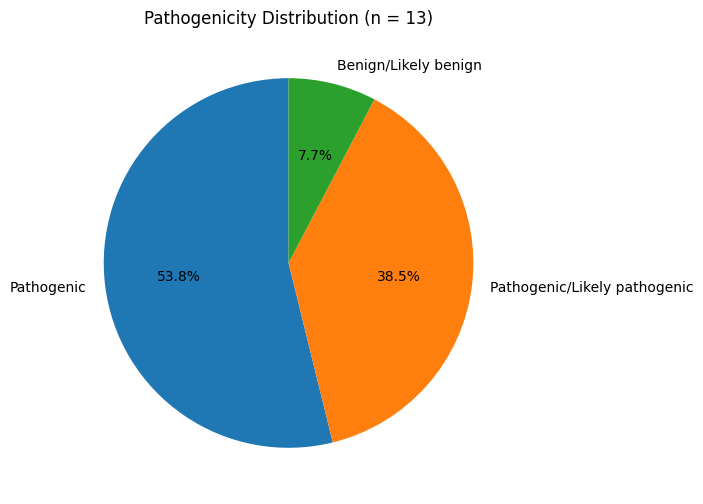

In [144]:
import matplotlib.pyplot as plt

# Count occurrences of each category
counts = grouped_df['pathogenicity_sum'].value_counts()

# Plot pie chart
counts.plot.pie(autopct='%1.1f%%', startangle=90, figsize=(6, 6))

plt.title(f"Pathogenicity Distribution (n = {grouped_df.shape[0]})")
plt.ylabel("")  # Optional: hide y-label
plt.show()


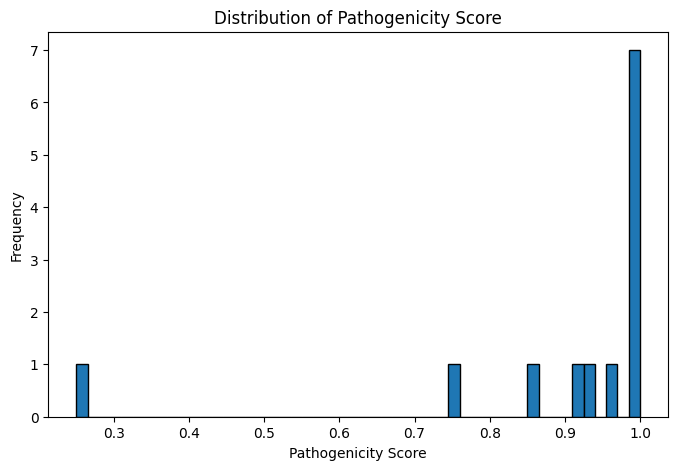

In [141]:
plt.figure(figsize=(8, 5))
grouped_df['pathogenicity_score'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Pathogenicity Score')
plt.xlabel('Pathogenicity Score')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()


In [142]:
def compute_confidence(row):
    score = 0
    criteria = ''
    
    # +1 if genomic_coord_result is not "-"
    if row['genomic_coord_result'] != "-":
        criteria += 'transcript found'
        score += 1

    # +1 if Num_of_paper_used > 1
    if row.get('Num_of_paper_used', 0) > 1:
        num_unknown = row.get('pathogenicity').count("unknown")
        
        if num_unknown < row.get("Num_of_record_used") - 1:
            if criteria !='':
                criteria +=';'
            criteria += 'multiple papers'
            score += 1
            
        # AND if pathogenicity_sum is not 'Conflicting' or 'Uncertain significance'
        if row.get('pathogenicity_sum') not in ['Conflicting', 'Uncertain significance']:
            if criteria !='':
                criteria +=';'
            criteria += 'consistant pathogenicity'
            score += 1
    
    if criteria == '':
        criteria = '-'
        
    return [score,criteria]

# Apply to DataFrame
grouped_df[['confidence', 'confidence_criteria']] = grouped_df.apply(compute_confidence, axis=1, result_type='expand')


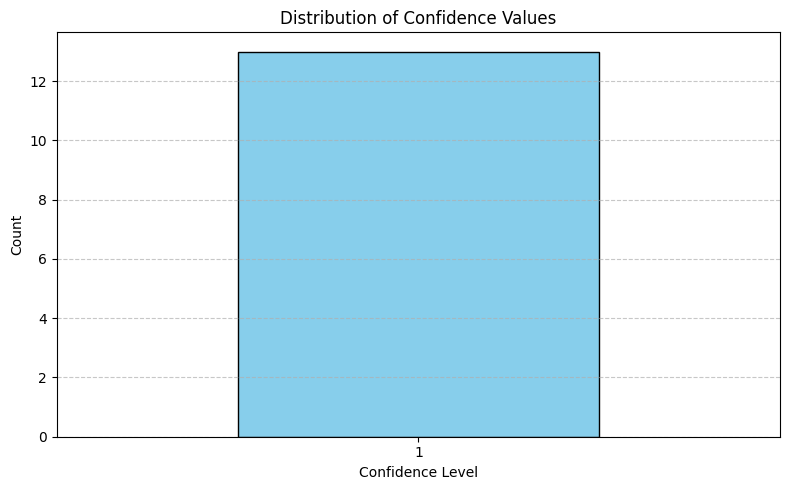

In [143]:
import matplotlib.pyplot as plt

# Plot the distribution (bar plot) for discrete confidence values
plt.figure(figsize=(8, 5))
grouped_df['confidence'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribution of Confidence Values')
plt.xlabel('Confidence Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [145]:
grouped_df

,gene,RSID,dna_change,aa_change,genomic_coord_result,parsed_variants,LLM_mutation,LLM reasoning,pathogenicity,formatted_reference,MONDO_name_09,HPO_term_09,disease,phenotype,Num_of_record_used,Num_of_paper_used,pathogenicity_sum,pathogenicity_score,confidence,confidence_criteria
0,AP4M1,-,G258del,-,"[{'transcript_id': 'ENST00000713591', 'chromos...","[{'chr': '7', 'pos': 100102867, 'ref': 'G', 'a...",c.258delG;p.A87Pfs*44 | c.258delG;p.A87Pfs*44 ...,"loss of function, disrupts proper intramolecul...",pathogenic | pathogenic | pathogenic | likely ...,PMC12858432(PMID:.):abstract | PMC12858432(PMI...,- | - | - | - | - | - | -,- | - | - | - | - | - | -,Spastic paraplegia 50 (SPG50) | - | - | - | - ...,"intellectual disability, seizures, muscle weak...",7,0,Pathogenic/Likely pathogenic,0.928571,1,transcript found
1,AP4M1,-,G258del,Ala87Profs*44,"[{'transcript_id': 'ENST00000713591', 'chromos...","[{'chr': '7', 'pos': 100102867, 'ref': 'G', 'a...",c.258delG;p.Ala87Profs*44,"premature termination, disruption of protein-p...",pathogenic,PMC12858432(PMID:.):Discussion,-,-,SPG50,-,1,0,Pathogenic,1.000000,1,transcript found
2,ATP2B1,-,-,-,None,[],-;p.Asp239Gly,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1,0,Pathogenic,1.000000,1,transcript found
3,ATP2B1,-,-,Arg763Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89610467, 'ref': 'TCG', ...",-;p.Arg763Pro,loss-of-function,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,-,1,0,Pathogenic,1.000000,1,transcript found
4,ATP2B1,-,-,Arg789Cys,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89610012, 'ref': 'GCG', ...",-;p.Arg789Cys,loss-of-function,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,-,1,0,Pathogenic,1.000000,1,transcript found
5,ATP2B1,-,-,Arg991Gln,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89603130, 'ref': 'CCG', ...",-;p.Arg991Gln,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1,0,Pathogenic,1.000000,1,transcript found
6,ATP2B1,-,-,Thr264Ile,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89630641, 'ref': 'AGT', ...",-;p.Thr264Ile,loss of calcium transport activity,pathogenic,PMC12992144(PMID:.):Discussion,-,-,MRD66,mislocalization phenotype,1,0,Pathogenic,1.000000,1,transcript found
7,ATP2B1,-,-,Thr714Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89611298, 'ref': 'AGT', ...",-;p.Thr714Pro | -;p.Thr714Pro | -;p.Thr714Pro ...,disrupts critical hydrogen bonding within the ...,pathogenic | pathogenic | unknown | pathogenic...,PMC12992144(PMID:.):Introduction | PMC12992144...,neurodevelopmental disorder | - | - | - | - | ...,- | - | - | - | - | - | - | - | - | -,neurodevelopmental disorder | - | - | - | - | ...,infantile spasms and GDD | steric clashes and ...,10,0,Pathogenic/Likely pathogenic,0.964286,1,transcript found
8,ATP2B1,-,A2140C,Thr714Pro,"[{'transcript_id': 'ENST00000359142', 'chromos...","[{'chr': '12', 'pos': 89611300, 'ref': 'T', 'a...",c.2140A>C;p.Thr714Pro | c.2140A>C;p.Thr714Pro ...,cytoplasmic mislocalization of the mutant prot...,pathogenic | likely pathogenic | unknown | pat...,PMC12992144(PMID:.):abstract | PMC12992144(PMI...,"intellectual developmental disorder, autosomal...",- | - | - | - | - | -,autosomal dominant intellectual developmental ...,"infantile spasms, global developmental delay (...",6,0,Pathogenic/Likely pathogenic,0.916667,1,transcript found
9,ATP2B1,-,T3060+2G,-,cdna_error: invalid literal for int() with bas...,[],c.3060 + 2T>G;-,"not determined by inheritance pattern alone, b...",likely benign,PMC12992144(PMID:.):Discussion,-,-,MRD66,asymptomatic,1,0,Benign/Likely benign,0.250000,1,transcript found


In [154]:
grouped_df.groupby(['gene','dna_change','aa_change']).count()[['RSID']]

RSID
gene   dna_change aa_change          
AP4M1  G258del    -                 1
                  Ala87Profs*44     1
ATP2B1 -          -                 1
                  Arg763Pro         1
                  Arg789Cys         1
                  Arg991Gln         1
                  Thr264Ile         1
                  Thr714Pro         1
       A2140C     Thr714Pro         1
       T3060+2G   -                 1
CYBA   -          -                 1
                  Gln58Ter          1
       C427T      Gln143Ter         1

In [155]:
df_whole_paper_out

,PMCID,section,gene,DNA mutation,protein mutation,disease,phenotype,LLM reasoning,pathogenicity
0,PMC12858432,full_text,AP4M1,c.258delG,p.A87Pfs*44,Spastic paraplegia 50 (SPG50),"intellectual disability, seizures, muscle weak...",loss of protein function due to premature term...,pathogenic
1,PMC12992144,full_text,"""",None,None,None,None,None,None
21,PMC12992144,full_text,,None,None,None,None,None,None
22,PMC12992144,full_text,ATP-type ATP2B1.,None,None,None,None,None,None
28,PMC12992144,full_text,ATP-type ATP2B1,None,None,None,None,None,None
32,PMC12992144,full_text,"ATP-type ATP2.""",None,None,None,None,None,None
407,PMC13044143,full_text,CYBA,c.427C>T,p.Q143*,"Chronic granulomatous disease (CGD), Autosomal...","Recurrent severe infections, phagocyte dysfunc...",Loss of the proline-rich C-terminal domain of ...,likely
408,PMC13044143,full_text,CYBA,likely pathogenic variant c.,None,None,None,None,None
409,PMC13044143,full_text,CYBA,"loss of Intron, autosomal immunodeficiency",likely pathogenic variant site,None,None,None,None


In [158]:
df_whole_paper_filtered_out

,PMCID,section,gene,DNA mutation,protein mutation,disease,phenotype,LLM reasoning,pathogenicity
0,PMC12858432,full_text_filtered,AP4M1,c.258delG,p.A87Pfs*44,Spastic paraplegia 50 (SPG50),"intellectual disability, seizures, muscle weak...",loss of protein function due to premature term...,pathogenic
1,PMC12992144,full_text_filtered,ATP2B1,c.2140A>C,p.Thr714Pro,autosomal dominant intellectual developmental ...,"global developmental delay, infantile spasms, ...",defective plasma membrane trafficking and intr...,likely pathogenic
2,PMC13044143,full_text_filtered,CYBA,c.427C>T,p.Q143*,chronic granulomatous disease type 4 (CGD),recurrent severe pneumonia and pleural effusion,nonsense mutation introducing a premature stop...,likely pathogenic
